# Analysis and Visualization of data

## Introduction
Our goal is to find out realtions between world happiness scores and factors like GDP, employment, etc. We will use several machine learning models to predict the happiness score based on the factors.

We also wish to see if different factors are more important in different regions of the world.

### Classification of problem
This is a regression problem, as we are trying to predict a continuous value, the happiness score.

### The data
The data is gathered from Kaggle, and is a combination of several datasets.
- World happiness report
- World employment data
- World economic data

### The Analysis
1. Mean, median, standard deviation
2. Correlation analysis
3. Linear Regression analysis
4. Neural Network
5. Decision Tree
6. Random Forest
7. Conclusion


## 0. Import dependencies and Load data

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


%matplotlib inline

# Load the dataset
if not Path('data/combined_data.csv').exists():
    raise Exception('Please run the scripts in the data_preprocessing notebook first. And make sure the data folder contains the combined_data.csv file.')

data = pd.read_csv('data/combined_data.csv')
mean_data = data[['Happiness_Score_Mean', 'Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]
data_without_mean = data.drop(columns=['Happiness_Score_Mean', 'Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean'])

# Check for null values and visualize the data
print(data.isnull().sum()[data.isnull().sum() > 0])
data.head()

Series([], dtype: int64)


,Country,Happiness_Score_2015,Happiness_Score_2016,Happiness_Score_2017,Happiness_Score_2018,Happiness_Score_2019,Happiness_Score_Mean,Unemployment_Rate_2015,Unemployment_Rate_2016,Unemployment_Rate_2017,...,GDP_Per_Capita_2017,GDP_Per_Capita_2018,GDP_Per_Capita_2019,GDP_Per_Capita_Growth_2015,GDP_Per_Capita_Growth_2016,GDP_Per_Capita_Growth_2017,GDP_Per_Capita_Growth_2018,GDP_Per_Capita_Growth_2019,GDP_Per_Capita_Mean,GDP_Per_Capita_Growth_Mean
0,Switzerland,7.587,7.509,7.494,7.487,7.480,7.5114,4.80,4.92,4.80,...,83352.088653,86388.404953,85334.519462,0.507122,0.936884,0.641284,2.161570,0.491609,84584.887063,0.947694
1,Iceland,7.561,7.501,7.504,7.495,7.494,7.5110,3.98,2.98,2.74,...,72010.149032,74469.804059,68941.462227,3.354145,4.838299,1.779410,2.120301,0.206935,66072.204638,2.459818
2,Denmark,7.527,7.526,7.522,7.555,7.600,7.5460,6.28,5.99,5.83,...,57610.098180,61591.928870,59775.735096,1.622166,2.443369,2.162355,1.485085,1.749614,57379.323378,1.892518
3,Norway,7.522,7.498,7.537,7.594,7.554,7.5410,4.30,4.68,4.16,...,75496.754058,82267.809316,75719.752897,0.957501,0.185060,1.500181,0.453550,0.067993,75660.078532,0.632857
4,Canada,7.427,7.404,7.316,7.328,7.278,7.3506,6.91,7.00,6.34,...,45129.356440,46548.520360,46338.340956,-0.089286,-0.135843,1.811115,1.335471,0.448132,44785.591400,0.673918


## 1. Mean, median, standard deviation
### Import Libraries and Load Data

### 1.1 Finding the mean, median and standard deviation of the data

In [6]:
# Calculate mean for each numerical column
mean_values = mean_data.mean()
print("\033[1mMean Values:\033[0m\n", mean_values)

# Calculate median for each numerical column
median_values = mean_data.median()
print("\n\033[1mMedian Values:\033[0m\n", median_values)

# Calculate standard deviation for each numerical column
std_values = mean_data.std()
print("\n\033[1mStandard Deviation:\033[0m\n", std_values)

Mean Values:
 Happiness_Score_Mean              5.492611
Unemployment_Rate_Mean            6.806762
GDP_Per_Capita_Mean           16072.635511
GDP_Per_Capita_Growth_Mean        2.079890
dtype: float64

Median Values:
 Happiness_Score_Mean             5.520400
Unemployment_Rate_Mean           5.142000
GDP_Per_Capita_Mean           6389.425415
GDP_Per_Capita_Growth_Mean       1.859906
dtype: float64

Standard Deviation:
 Happiness_Score_Mean              1.125285
Unemployment_Rate_Mean            5.110151
GDP_Per_Capita_Mean           21229.200866
GDP_Per_Capita_Growth_Mean        2.224346
dtype: float64


### 1.2 Visualize data

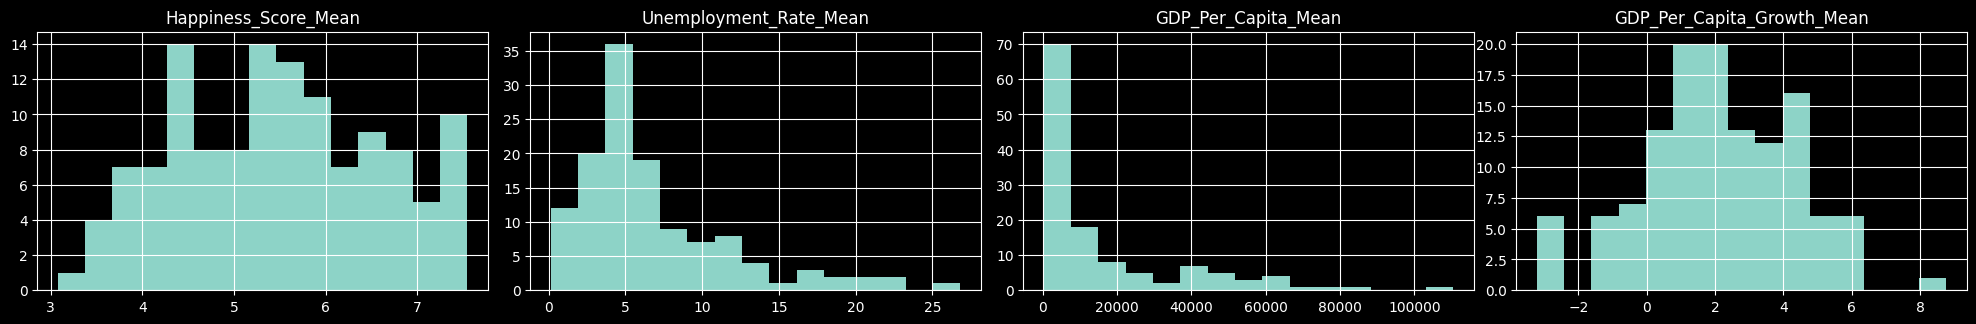

In [7]:
# Plot histograms
mean_data.hist(bins=15, figsize=(20, 15), layout=(5, 4))
plt.tight_layout()
plt.show()

## 2. Correlation analysis

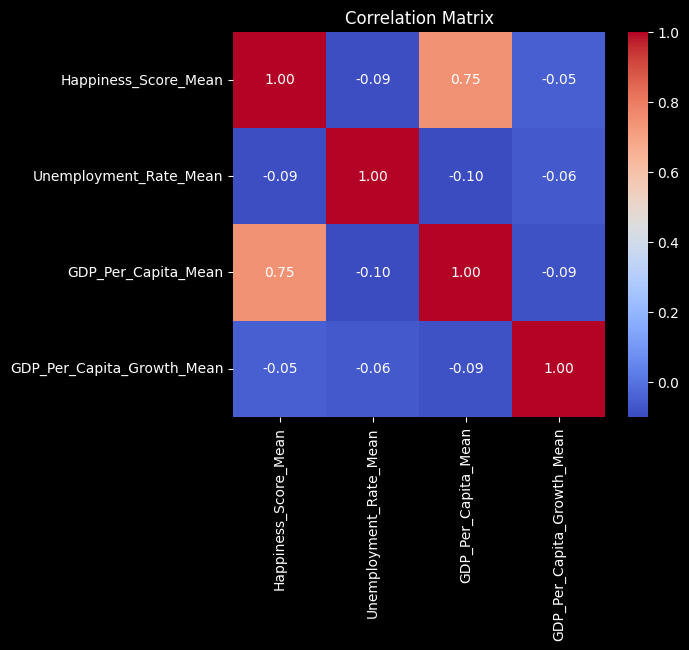

In [8]:
# Compute correlation matrix
corr_matrix = mean_data.corr()

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

## 3. Regression analysis
### 3.1 Simple Linear Regression

In [9]:
X = data[['Unemployment_Rate_Mean']]
y = data['Happiness_Score_Mean']
X_train, X_test_simple, y_train, y_test_simple = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Coefficient
print("Coefficient:", linear_model.coef_)

# Intercept
print("Intercept:", linear_model.intercept_)

y_pred_simple = linear_model.predict(X_test_simple)

Coefficient: [-0.02685319]
Intercept: 5.631634185198115


### 3.2 Multiple Linear Regression

In [10]:
X = data[['Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]
y = data['Happiness_Score_Mean']
X_train, X_test_multiple, y_train, y_test_multiple = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Linear Regression model
multiple_linear_model = LinearRegression()

# Train the model
multiple_linear_model.fit(X_train, y_train)

# Coefficient
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': multiple_linear_model.coef_
})
print(coefficients)

# Intercept
print("Intercept:", multiple_linear_model.intercept_)

y_pred_multiple = multiple_linear_model.predict(X_test_multiple)

                     Variable  Coefficient
0      Unemployment_Rate_Mean    -0.007357
1         GDP_Per_Capita_Mean     0.000039
2  GDP_Per_Capita_Growth_Mean    -0.003245
Intercept: 4.856964094281782


### 3.3 Visualizing the results

In [11]:
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mse_multiple = mean_squared_error(y_test_multiple, y_pred_multiple)

r2_simple = r2_score(y_test_simple, y_pred_simple)
r2_multiple = r2_score(y_test_multiple, y_pred_multiple)

print("\n\033[1mPerformance:\033[0m\n")
print("Simple Linear Regression Model:")
print("MSE:", mse_simple)
print("R^2:", r2_simple)
print("\nMultiple Linear Regression Model:")
print("MSE:", mse_multiple)
print("R^2:", r2_multiple)


Performance:

Simple Linear Regression Model:
MSE: 1.269442042286362
R^2: -0.04951689087939837

Multiple Linear Regression Model:
MSE: 0.6352359290454423
R^2: 0.47481585214721755


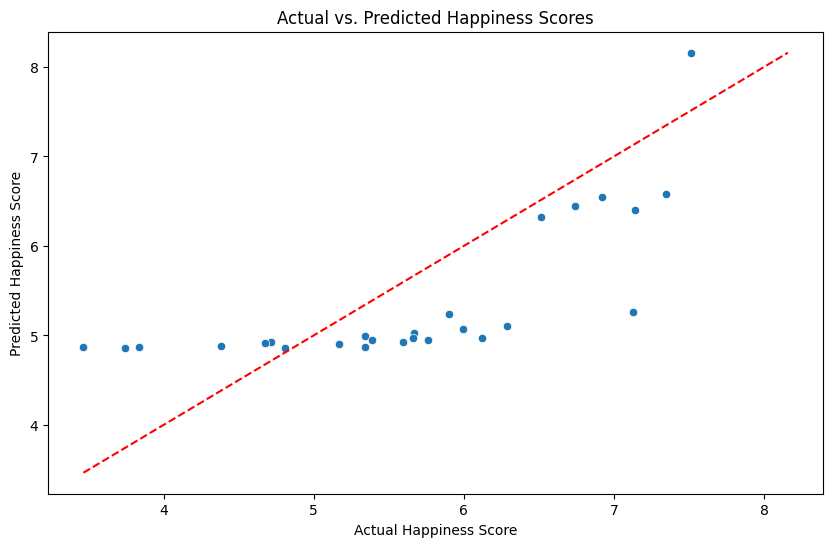

In [74]:
# Create a DataFrame with actual and predicted values
results_df = pd.DataFrame({'Actual': y_test_multiple, 'Predicted': y_pred_multiple})

# Plot the results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results_df)
plt.plot([results_df.min().min(), results_df.max().max()], [results_df.min().min(), results_df.max().max()], 'r--')
plt.title('Actual vs. Predicted Happiness Scores')
plt.xlabel('Actual Happiness Score')
plt.ylabel('Predicted Happiness Score')
plt.show()

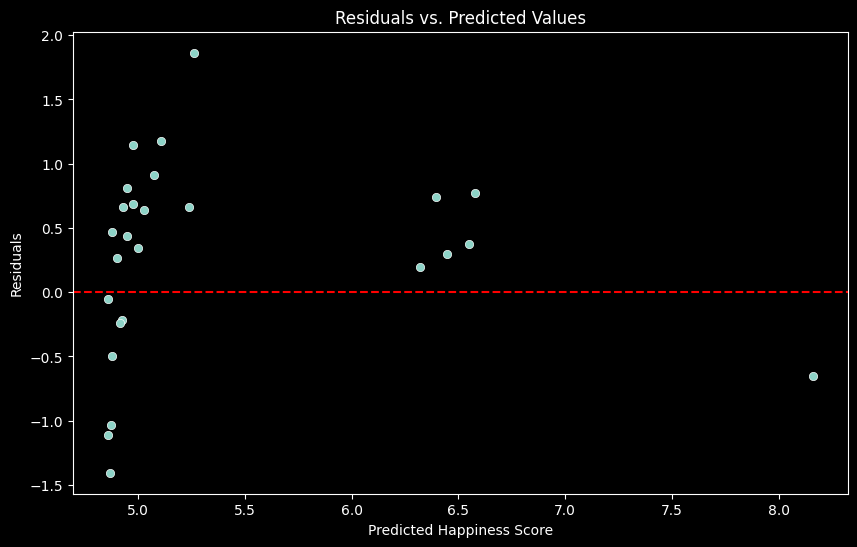

In [12]:
# Calculate residuals
residuals = y_test_multiple - y_pred_multiple

# Plot residuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_multiple, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Happiness Score')
plt.ylabel('Residuals')
plt.show()

## 4. Neural Network

### 4.1 Scale features

In [ ]:
from sklearn.preprocessing import StandardScaler

X = data[['Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]
y = data['Happiness_Score_Mean']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X=X_test)

TypeError: StandardScaler.transform() missing 1 required positional argument: 'X'

### 4.2 Train the model

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Define the neural network architecture
model = Sequential()
model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))  # For regression

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_scaled, y_train, 
                    validation_split=0.1, 
                    epochs=100, 
                    batch_size=32, 
                    verbose=1)

ImportError: Traceback (most recent call last):
  File "/Users/christianveiby/Lokale dokumenter/ME276DS-SDSE-The-Happiness-Project/env/lib/python3.13/site-packages/tensorflow/python/pywrap_tensorflow.py", line 58, in <module>
    from tensorflow.python.pywrap_tensorflow_internal import *
  File "/Users/christianveiby/Lokale dokumenter/ME276DS-SDSE-The-Happiness-Project/env/lib/python3.13/site-packages/tensorflow/python/pywrap_tensorflow_internal.py", line 28, in <module>
    _pywrap_tensorflow_internal = swig_import_helper()
  File "/Users/christianveiby/Lokale dokumenter/ME276DS-SDSE-The-Happiness-Project/env/lib/python3.13/site-packages/tensorflow/python/pywrap_tensorflow_internal.py", line 15, in swig_import_helper
    import imp
ModuleNotFoundError: No module named 'imp'


Failed to load the native TensorFlow runtime.

See https://www.tensorflow.org/install/errors

for some common reasons and solutions.  Include the entire stack trace
above this error message when asking for help.

### 4.3 Evaluate the model

In [ ]:
# Evaluate on the test set
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print("\nNeural Network Results:")
print("Test MSE (loss):", loss)
print("Test MAE:", mae)

# Make predictions
y_pred_nn = model.predict(X_test_scaled).flatten()

mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print("Calculated MSE:", mse_nn)
print("R-squared:", r2_nn)

## 5. Decision Tree

In [1]:
from sklearn.tree import DecisionTreeRegressor

X = data[['Unemployment_Rate_Mean', 'GDP_Per_Capita_Mean', 'GDP_Per_Capita_Growth_Mean']]
y = data['Happiness_Score_Mean']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predict on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate performance
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MSE:", mse_dt)
print("R-squared:", r2_dt)

NameError: name 'data' is not defined

## 6. Random Forest

In [10]:
from sklearn.ensemble import RandomForestRegressor

# Create and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Results:")
print("MSE:", mse_rf)
print("R-squared:", r2_rf)


Random Forest Results:
MSE: 0.30029425980940333
R-squared: 0.7517303764916584


## 7. Conclusion